# **Discussion Related With Outliers And Impact On Machine Learning!!**

### **Outliers:**

**In statistics/data analysis:**
An outlier is a data point that differs significantly from the rest of the data in a set. For example, if most people in a room earn $40,000–$60,000 a year and one person earns $5 million, that person's income is an outlier. Outliers can result from natural variation, measurement error, or something genuinely unusual — and they're important to identify because they can skew averages, distort statistical models, and sometimes reveal interesting anomalies worth investigating.

**Kab outliers REMOVE karne chahiye**

1. Data entry ya measurement error ho

---> Jaise kisi ne age "250" enter kar diya, ya weight "-5 kg" hai — ye clearly galat hai, remove karo.

2. Duplicate ya irrelevant data

---> Wrong population se aaya data point (jaise test data production data mein mix ho gaya).

3. Model bahut sensitive ho outliers se

---> Linear regression, mean-based analysis, ya distance-based algorithms (KNN, K-means) outliers se bahut affect hote hain. Agar outlier genuinely rare/one-off event hai aur aapka goal "typical pattern" samajhna hai, to remove/treat karna better hai.

4. Aapka objective "central tendency" samajhna hai

---> Jaise average salary ka trend dekhna hai, aur ek CEO ka salary sabko skew kar raha hai.

**Kab outliers REMOVE NAHI karne chahiye**

1. Outlier hi important information hai

---> Fraud detection, anomaly detection, disease outbreak detection — yahan outliers hi asli signal hain! Unhe remove karna matlab poora point miss karna.

2. Genuine variation ho

---> Real-world extreme values (jaise koi genuinely bahut talented student jo sabse alag score kare) — ye valid data hai, sirf "अजीब" lagne se remove mat karo.

3. Sample size chota ho

---> Agar data already limited hai, to outliers remove karne se aur bhi kam data reh jayega aur bias aa sakta hai.

4. Tree-based models use kar rahe ho

---> Decision Trees, Random Forest, XGBoost jaise models outliers se utna affect nahi hote — inme removal ki zaroorat kam hoti hai.

**Practical approach**

1. Pehle samjho kyun outlier hai (error vs genuine)
2. Visualize karo (boxplot, scatter plot)
3. Domain knowledge use karo — ek statistician yeh decide nahi kar sakta, business context matter karta hai
4. Agar unsure ho, to remove karne ke bajaye "flag" ya "cap" (winsorize) karna better option hota hai — data delete nahi hota, effect kam ho jata hai






**Which Machine Learning Models Are Sensitive To Outliers?**

1. Naivaye bayes Classifier--- Not sensitive To Outliers
2. SVM----- Not Sensitive To Outliers

3. Linear Regression---- Sensitive To Outliers

4. Logistic Regression---Sensitive To Outliers
5. Decision Tree Regressor or Classifier---- Not Sensitive To Outliers
6. Ensemble(RF,XGboost,GB)--- Not Sensitive To Outliers

7. KNN---- Not Sensitive To Outliers
8. K-means--- Sensitive To Outliers
9. Hierarichal---- Sensitive To Outliers
10. PCA--- Sensitive To Outliers
11. Neural Networks--- Sensitive To Outliers


In [198]:
import pandas as pd

In [199]:
df=pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [200]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [201]:
df['Age'].isnull().sum()

np.int64(177)

In [202]:
import matplotlib.pyplot as plt

import seaborn as sns
%matplotlib inline

/tmp/ipykernel_1316/615646242.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'].dropna())


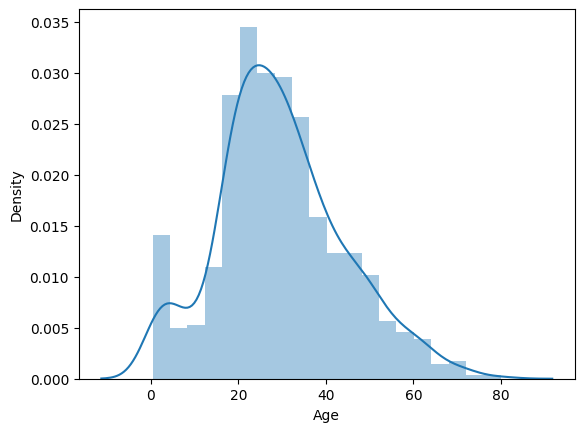

In [203]:
sns.distplot(df['Age'].dropna())
plt.show()

/tmp/ipykernel_1316/827162487.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'].fillna(100))


<Axes: xlabel='Age', ylabel='Density'>

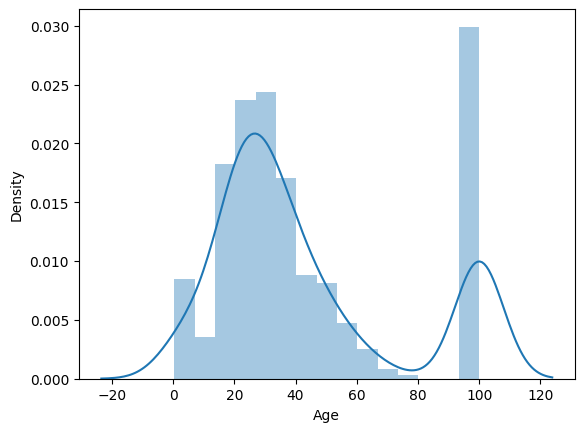

In [204]:
sns.distplot(df['Age'].fillna(100))

## **Outliers In Case Of Gaussian Distribution**

#### **Interview**
Gaussian Distribution And Normal Distribution Both Are Same:->


Haan, dono terms same cheez ko refer karte hain — "Gaussian distribution" aur "Normal distribution" interchangeably use hote hain.

**Thoda background:**

1. Isko "Normal" isliye kehte hain kyunki naturally occurring bahut si phenomena (height, weight, measurement errors, etc.) approximately isi distribution ko follow karti hain.
2. Isko "Gaussian" isliye kehte hain kyunki mathematician Carl Friedrich Gauss ne is distribution ko formally study kiya tha (though isse pehle Abraham de Moivre ne bhi iska zikr kiya tha).

3. Mathematically, dono ek hi formula/curve ko represent karte hain:

     f(x) = 1/(σ√(2π)) * e^(-(x-μ)²/(2σ²))

Jahan:

> μ (mu) = mean


> σ (sigma) = standard deviation

4. Characteristics (dono ke same hote hain):

i. Bell-shaped curve


ii. Symmetric around mean

iii. Mean = Median = Mode


iv. 68-95-99.7 rule (empirical rule) follow karta hai

-> Data science/ML context mein jab bhi koi bole "assume the data is normally distributed" ya "Gaussian distributed", matlab same hi hota hai — koi difference nahi hai in usage mein.
	​





Text(0, 0.5, 'No Of Passenger')

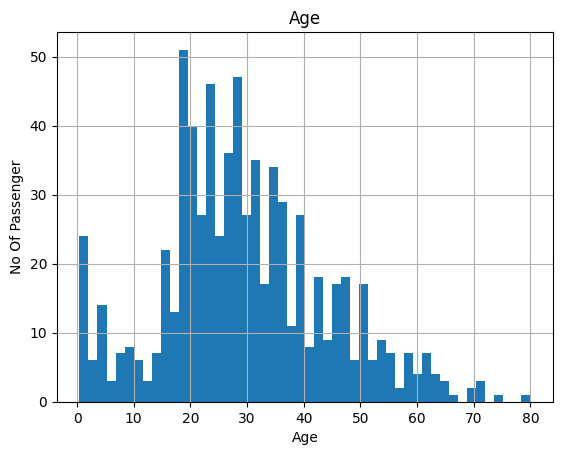

In [205]:
figure=df.Age.hist(bins=50)
figure.set_title('Age')
figure.set_xlabel('Age')
figure.set_ylabel('No Of Passenger')

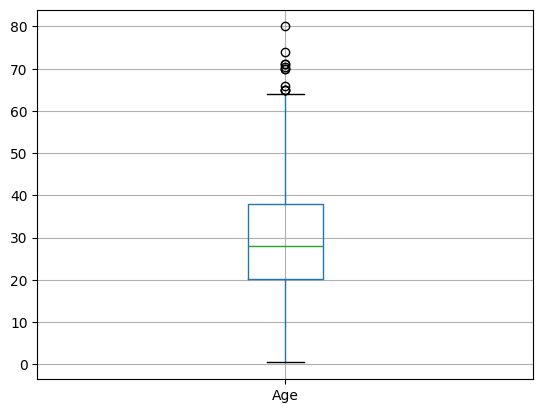

In [206]:
figure=df.boxplot(column='Age')

In [207]:
df['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


**If The Data Is Normally Distributed We use this**

In [208]:
# Case-1 (Exterme Outliers)
##### Assuming Age follows A Gaussian Distribution we will calculate the boundaries which differentiates the outliers
mean=df.Age.mean()
upper_boundary=df['Age'].mean() + 3*df['Age'].std()
lower_boundary=df['Age'].mean()-3*df['Age'].std()
print("lower_boundary:",lower_boundary), print("mean:",mean), print("upper_boundary:",upper_boundary)


lower_boundary: -13.88037434994331
mean: 29.69911764705882
upper_boundary: 73.27860964406095


(None, None, None)

In [209]:
### Let's compute the Interquantile range to calculate the boundaries.
IQR=df.Age.quantile(0.75)-df.Age.quantile(0.25)

In [210]:
# Case-2
lower_fance=df['Age'].quantile(0.25)-(IQR*1.5)
upper_fance=df['Age'].quantile(0.75)+(IQR*1.5)
print(lower_fance), print(upper_fance)

-6.6875
64.8125


(None, None)

Here -6.6875 is not considered because age is not negative values.

## **Outliers In Case Of Skewed Distribution**

**If The Feature Is skewed We use the below Technique**

Text(0, 0.5, 'No Of Passenger')

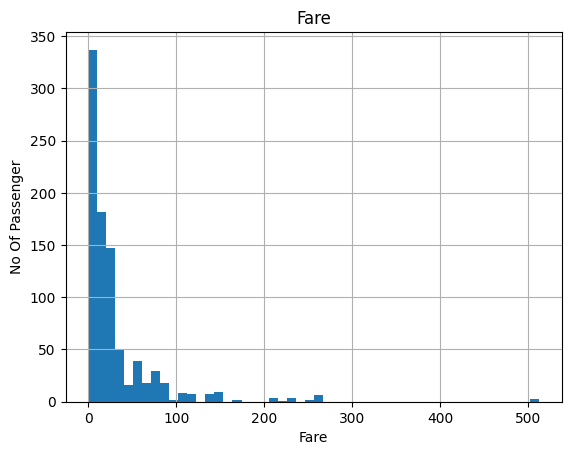

In [211]:
figure=df.Fare.hist(bins=50)
figure.set_title('Fare')
figure.set_xlabel('Fare')
figure.set_ylabel('No Of Passenger')

<Axes: >

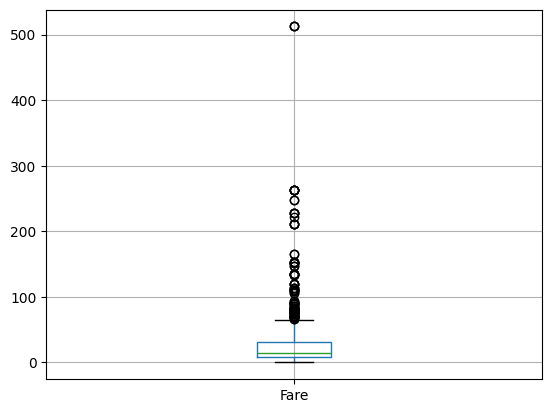

In [212]:
df.boxplot(column='Fare')

In [213]:
df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


In [214]:
### Let's compute the Interquantile range to calculate the boundaries.
IQR=df.Fare.quantile(0.75)-df.Fare.quantile(0.25)

In [215]:
# In this case it is not perform well
lower_fance=df['Fare'].quantile(0.25)-(IQR*1.5)
upper_fance=df['Fare'].quantile(0.75)+(IQR*1.5)
print(lower_fance), print(upper_fance)

-26.724
65.6344


(None, None)

In [216]:
# In this case this technique is perform awesome
### Extreme Outliers
lower_fance=df['Fare'].quantile(0.25)-(IQR*3)
upper_fance=df['Fare'].quantile(0.75)+(IQR*3)
print(lower_fance), print(upper_fance)

-61.358399999999996
100.2688


(None, None)

**Handle Outliers**

In [217]:
data=df.copy()

In [218]:
# In case of Age
data.loc[data['Age']>=73,'Age']=73


Text(0, 0.5, 'No Of Passenger')

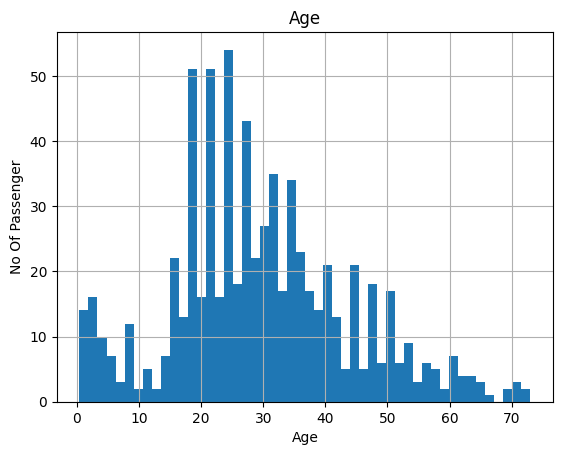

In [219]:
figure=data.Age.hist(bins=50)
figure.set_title('Age')
figure.set_xlabel('Age')
figure.set_ylabel('No Of Passenger')

In [220]:
# In case of Fare
data.loc[data['Fare']>100,'Fare']=100

Text(0, 0.5, 'No Of Passenger')

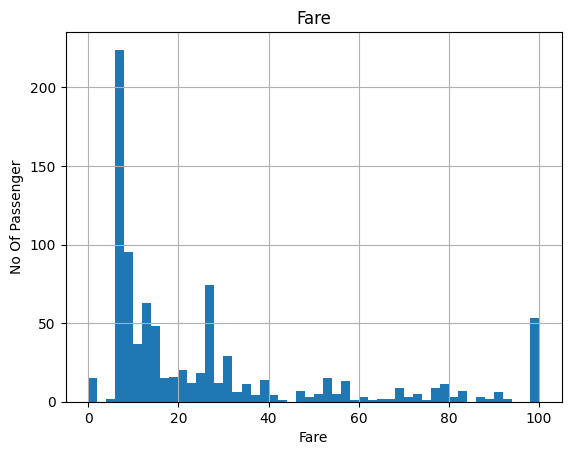

In [221]:
figure=data.Fare.hist(bins=50)
figure.set_title('Fare')
figure.set_xlabel('Fare')
figure.set_ylabel('No Of Passenger')

In [222]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(data[['Age','Fare']].fillna(0),data['Survived'],test_size=0.3,random_state=45)

In [223]:
### Logistic Regression
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression()
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)
y_pred1=classifier.predict_proba(X_test)

from sklearn.metrics import accuracy_score,roc_auc_score
print("Accuracy_score: {}".format(accuracy_score(y_test,y_pred)))
print("roc_auc_score: {}".format(roc_auc_score(y_test,y_pred1[:,1])))

Accuracy_score: 0.7014925373134329
roc_auc_score: 0.6804931335830211


In [224]:
### RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier()
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)
y_pred1=classifier.predict_proba(X_test)

from sklearn.metrics import accuracy_score,roc_auc_score
print("Accuracy_score: {}".format(accuracy_score(y_test,y_pred)))
print("roc_auc_score: {}".format(roc_auc_score(y_test,y_pred1[:,1])))

Accuracy_score: 0.6305970149253731
roc_auc_score: 0.6769038701622972
